# Config

In [33]:
!git config --global --add safe.directory /tmp/Repository/VRID_language_proyect

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [34]:
import os

# Ruta a la que quieres mover el path
nueva_ruta = "/tmp/Repository/VRID_language_proyect/BERT"

# Cambiar el directorio actual
os.chdir(nueva_ruta)

# Confirmar que cambió
print("Directorio actual:", os.getcwd())

Directorio actual: /tmp/Repository/VRID_language_proyect/BERT


In [35]:
import pandas as pd
import os
from preprocess.preprocess import clean_text, check_deleted_expressions
from preprocess.translate import translator, gen_text_for_embedding, final_clean, detect_language
import time
import json
import numpy as np

# Preparación de texto

In [4]:
# 1) Cargar datos
path = "/tmp/ocde/new_data"

#Cargar titulo, keys, etc.
filePATH = os.path.join(path, "old_data.xlsx")
df_data = pd.read_excel(filePATH, usecols=["Código VRID", "Título", "Keywords", "Resumen", "Depto Persona",
                                           "Facultad del Proyecto"])

#Cargar desafíos
filePATH = os.path.join(path, "new_data.xlsx")
#Pagina 0
df_ocde0 = pd.read_excel(os.path.join(path, filePATH), usecols=["Código VRID", "Categoria Disciplina", 
                                             "Sub Area Disciplina", "Tipo Área Disciplina"], sheet_name=2)
#Pagina 1
df_ocde1 =  pd.read_excel(os.path.join(path, filePATH), usecols=["Código VRID", "Categoria Disciplina", 
                                             "Sub Area Disciplina", "Tipo Área Disciplina"], sheet_name=3)

df_labels = pd.concat([df_ocde0, df_ocde1])


#Codes unique
codes_unique = df_labels["Código VRID"].astype(str).unique()
print(codes_unique.shape)
print(df_data.shape, df_labels.shape)
print(np.unique(df_data["Código VRID"].astype(str)).shape)
print(np.unique(df_labels["Código VRID"].astype(str)).shape)

(565,)
(1083, 6) (645, 4)
(1083,)
(565,)


In [ ]:
df_data["Código VRID"] = df_data["Código VRID"].astype(str)
df_labels["Código VRID"] = df_labels["Código VRID"].astype(str)


# Merge en base a "Código VRID"
df_merged = pd.merge(
    df_data,
    df_labels,
    on="Código VRID",       # columna clave
    how="inner"             # inner = solo los que coinciden en ambos
)
#Eliminar dupliados
df_merged = df_merged.drop_duplicates(subset=["Código VRID"], keep="first")
print(df_merged.shape)                                                                                                                                
#print(np.unique(df_merged["Código VRID"].astype(str)).shape)
print(df_merged["Categoria Disciplina"].value_counts())

#save dataframe
savepath=os.path.join(path, "data_concatenada.csv")
df_merged.to_csv(savepath, index=False, encoding="utf-8-sig")

(429, 9)
CIENCIAS NATURALES                        212
 INGENIERÍA, TECNOLOGÍA                    77
CIENCIAS SOCIALES                          60
CIENCIAS AGRÍCOLAS                         33
HUMANIDADES                                26
CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD     21
Name: Categoria Disciplina, dtype: int64


# 1) Preprocesamiento de los datos


In [ ]:
# 1) Cargar datos
path = "/tmp/ocde/new_data"
filePATH = os.path.join(path, "data_concatenada.csv")
df = pd.read_csv(filePATH)

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Título": "Titulo_trad",
    "Resumen": "Resumen_trad",
    "Keywords": "keywords_trad",
    "Depto Persona": "Depto_Persona_trad",
    "Facultad del Proyecto": "Facultad_del_Proyecto_trad", 
}
#Preprocesamiento de datos
df[list(cols.values())] = df[list(cols.keys())].applymap(clean_text)
savepath=os.path.join(path, "data_clean.csv")
#df.to_csv(savepath, index=False, encoding="utf-8-sig")

# 2) Traducción del texto

In [50]:
#Crear columna de registro de idioma: 
# True: Texto en español, False: Texto en inglés
df["Español"]=detect_language(df["Resumen_trad"])

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

#1. Cargar modelo de traducción
model_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
trans = translator(model, tokenizer)

#Columnas que se van a traducir
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Titulo_trad": "Titulo_trad",
    "Resumen_trad": "Resumen_trad",
    "keywords_trad": "keywords_trad",
    "Facultad_del_Proyecto_trad": "Facultad_del_Proyecto_trad",
    "Depto_Persona_trad": "Depto_Persona_trad",
}

#2. Traducción de columnas
#####Estoy trabajando en mejorar esta parte para que sea más rápida con paralelización por batches
start = time.time()
for src, dst in cols.items():
    df[dst] = trans.translate_parallel(df[src].to_list(), batch_size=8)
end = time.time()

#3.Guardado de resultados
savepath=os.path.join(path, "data_translated.csv")
df.to_csv(savepath, index=False, encoding="utf-8-sig")

print(f"Tiempo total de traducción: {end - start:.2f} segundos")

In [53]:
df.head()

,Código VRID,Título,Keywords,Resumen,Facultad del Proyecto,Depto Persona,Categoria Disciplina,Sub Area Disciplina,Tipo Área Disciplina,Titulo_trad,Resumen_trad,keywords_trad,Depto_Persona_trad,Facultad_del_Proyecto_trad,Español
0,11170959,PRE-AND POST-NATAL EXPRESSION OF SLIT2 AND ITS...,"NEUROBLAST MIGRATION, SLIT2, LATERAL VENTRICLE...",IN THE SUBVENTRICULAR ZONE (SVZ) OF THE ADULT ...,FACULTAD DE CIENCIAS BIOLÓGICAS,DEPARTAMENTO DE FARMACOLOGÍA,CIENCIAS NATURALES,BIOLOGÍA,OCDE,pre-and post-natal expression of slit2 and its...,in the subventricular zone (svz) of the adult ...,"neuroblast migration, slit2, lateral ventricle...",department of pharmacology,Faculty of Life Sciences,False
1,11181200,"""DEVELOPMENT AND VALIDATION OF AN ANALYTICAL P...","CHROMATOGRAPHY-MASS SPECTROMETRY, UNTARGETED M...",_x000D_\nACCORDING TO THE INTERNATIONAL AGENCY...,FACULTAD DE FARMACIA,DEPARTAMENTO DE ANÁLISIS INSTRUMENTAL,CIENCIAS NATURALES,QUÍMICA,OCDE,"""development and validation of an analytical p...",according to the international agency for rese...,"chromatography-mass spectrometry, untargeted m...",departamento de análisis instrumental,faculty of pharmacy,False
2,11190637,TRANSGENERATIONAL AND WITHIN-GENERATION PLASTI...,NaN,NaN,FACULTAD DE CIENCIAS NATURALES Y OCEANOGRÁFICAS,DEPARTAMENTO DE ZOOLOGÍA,"CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD",MEDICINA BÁSICA,OCDE,transgenerational and within-generation plasti...,,,zoology department,Faculty of Natural and Oceanographic Sciences,False
3,11190698,: DESIGN AND SYNTHESIS OF ENANTIOPURE HYDROISO...,"HYDROISOQUINOLINES, ORGANOCATALYSIS, TANDEM RE...","IN THE LAST DECADES, THE SYNTHESIS OF NATURAL ...",FACULTAD DE CIENCIAS QUÍMICAS,DEPARTAMENTO DE QUÍMICA ORGÁNICA,CIENCIAS NATURALES,OTRAS CIENCIAS NATURALES,OCDE,design and synthesis of enantiopure hydroisoqu...,"in the last decades, the synthesis of natural ...","hydroisoquinolines, organocatalysis, tandem re...",Department of Organic Chemistry,Faculty of Chemical Sciences,False
4,11190906,CRYPTIC SPECIATION IN THE SOUTHERN OCEAN: INTE...,"SOUTHERN OCEAN, CRYPTIC SPECIATION, MARINE INV...","SINCE THE ISOLATION OF ANTARCTICA, THE INTERAC...",FACULTAD DE CIENCIAS NATURALES Y OCEANOGRÁFICAS,DEPARTAMENTO DE ZOOLOGÍA,CIENCIAS NATURALES,BIOLOGÍA,OCDE,cryptic speciation in the southern ocean: inte...,"since the isolation of antarctica, the interac...","southern ocean, cryptic speciation, marine inv...",zoology department,Faculty of Natural and Oceanographic Sciences,False


# 3) Split dataset

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from utils.dataset import to_serializable
import json

path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "data_translated.csv")
df = pd.read_csv(filepath)


In [ ]:
le = LabelEncoder()
df["labels"] = le.fit_transform(df["Categoria Disciplina"].astype(str))

# Convertir a arrays
ids = df["Código VRID"].to_numpy()
labels = df["labels"].to_numpy()

# Train/Test split (ids y labels en paralelo)
idx_train, idx_test, y_train, y_test = train_test_split(
    ids,
    labels,
    test_size=0.2,
    random_state=7,
    stratify=labels
)

# Crear folds sobre train
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)

folds = []
for fold, (train_pos, val_pos) in enumerate(skf.split(idx_train, y_train)):
    train_ids = idx_train[train_pos]   # array de IDs
    val_ids = idx_train[val_pos]       # array de IDs
    folds.append(val_ids)

print("Test size:", len(idx_test))
print("Fold 0 - Val size:", len(folds[0]))

#Guardar index en diccionario
dataset_index = {
    "Train": idx_train,
    "Test": idx_test,
    "kfolds": folds 
}
filepath=os.path.join(path, "new_data_ids_3folds.json")

# Guardar
#with open(filepath, "w", encoding="utf-8") as f:
#    json.dump(dataset_index, f, default=to_serializable, indent=2, ensure_ascii=False)

Test size: 82
Fold 0 - Val size: 109


# 4) TF-ID feature extractor 

## Train

In [121]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated.csv")
df = pd.read_csv(filepath)

In [18]:
df["Categoria Disciplina"].shape

(409,)

In [ ]:
#df["Categoria Disciplina"].shape
#df["Categoria Disciplina"].value_counts()

elements = ["CIENCIAS NATURALES", "INGENIERÍA, TECNOLOGÍA", "CIENCIAS SOCIALES", 
             "CIENCIAS AGRÍCOLAS", "HUMANIDADES", "CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD"]

# Clean spaces
df["Categoria Disciplina"] = df["Categoria Disciplina"].str.strip()

# Create one-hot encoded columns
for cat in elements:
    df[cat] = (df["Categoria Disciplina"] == cat).astype(int)


In [123]:
from sklearn.preprocessing import LabelEncoder
from models.TIFD import gen_TFID_vectors
from utils.dataset import gen_dataset_select_cols, binarize_labels
import numpy as np


#Lectura de codigos 
codes_test = dataset_index["Test"]
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
col_test = "CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD"
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols, 
                                                     test_col=col_test)
df_decode = df_train[["idx", "Código VRID"]]

#Creacion de vectores TFID
X_train, X_test = gen_TFID_vectors(X_train, X_test)
print(X_train.shape, X_test.shape)

#Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print(y_train.shape, y_test.shape)


(327, 11947) (82, 11947)
(327,) (82,)


In [124]:
from collections import Counter
print("Train label distribution:", Counter(y_train))
print("Test label distribution:", Counter(y_test))

Train label distribution: Counter({0: 310, 1: 17})
Test label distribution: Counter({0: 78, 1: 4})


In [125]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model#, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    'RandomForestClassifier',
    'XGBClassifier',
    'SVC',
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring='f1_macro'

#from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(random_state=7, shuffle=True)
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=skf, 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({0: 310, 1: 17})
📊 test: Counter({0: 78, 1: 4})
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [1.0, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbf

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.57, 'std_test_score': 0.1}
RandomForestClassifier: {'mean_test_score': 0.49, 'std_test_score': 0.0}
XGBClassifier: {'mean_test_score': 0.57, 'std_test_score': 0.1}
SVC: {'mean_test_score': 0.58, 'std_test_score': 0.11}


In [126]:
from utils.mlflow import eval_model
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results, preds=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.9512195121951219, 'f1_macro': 0.4875, 'cm': array([[78,  0],
       [ 4,  0]]), 'precision': 0.0, 'recall': 0.0, 'f1_es': 0.8861538461538463, 'f1_en': 0.9467532467532467, 'cm_es': array([[24,  0],
       [ 2,  0]]), 'cm_en': array([[54,  0],
       [ 2,  0]])}
RandomForestClassifier
{'accuracy': 0.9512195121951219, 'f1_macro': 0.4875, 'cm': array([[78,  0],
       [ 4,  0]]), 'precision': 0.0, 'recall': 0.0, 'f1_es': 0.8861538461538463, 'f1_en': 0.9467532467532467, 'cm_es': array([[24,  0],
       [ 2,  0]]), 'cm_en': array([[54,  0],
       [ 2,  0]])}
XGBClassifier
{'accuracy': 0.9390243902439024, 'f1_macro': 0.48427672955974843, 'cm': array([[77,  1],
       [ 4,  0]]), 'precision': 0.0, 'recall': 0.0, 'f1_es': 0.8861538461538463, 'f1_en': 0.937745740498034, 'cm_es': array([[24,  0],
       [ 2,  0]]), 'cm_en': array([[53,  1],
       [ 2,  0]])}
SVC
{'accuracy': 0.9512195121951219, 'f1_macro': 0.4875, 'cm': array([[78,  0],
       [ 4,  0]]), 'prec

## Save

In [127]:
from utils.mlflow import mlflow_ckeckpoint

# Guardar en MLflow
exp_info = {
    'exp_name': "Bayesiansearchcv_OCDE_all_results",
}

extra_parms = {
    "vectorization_model": "TF-IDF",
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "cols": cols,
    "ocde area": col_test,
}

extra_artifacts = {
    "dataset_data_splits": dataset_index,
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, X_test, y_test, df_test, save_preds=True, lang_es=lang_es, extra_parms=extra_parms, extra_artifacts=extra_artifacts, mode="server", mode_classification="binary")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/22 02:40:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/22/runs/be9559bab1384c1cac70e929978319f9
🧪 View experiment at: http://mlflow-server:5000/#/experiments/22
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/22 02:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/22/runs/a208bb48a53749a09892df3abc3dbc4b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/22
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/22 02:40:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/22/runs/1fac1f2fd31b4be7b89566a2460dbbdb
🧪 View experiment at: http://mlflow-server:5000/#/experiments/22
📝 Registrando modelo en MLflow: SVC


2025/09/22 02:40:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/22/runs/506597455f6c476488c27b467c7a22f9
🧪 View experiment at: http://mlflow-server:5000/#/experiments/22


# 5) SPECTER

## Train

In [15]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated.csv")
df = pd.read_csv(filepath)

In [28]:
df["Categoria Disciplina"].shape
df["Categoria Disciplina"].value_counts()

elements = ["CIENCIAS NATURALES", "INGENIERÍA, TECNOLOGÍA", "CIENCIAS SOCIALES", 
             "CIENCIAS AGRÍCOLAS", "HUMANIDADES", "CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD"]

# Clean spaces
df["Categoria Disciplina"] = df["Categoria Disciplina"].str.strip()

# Create one-hot encoded columns
for cat in elements:
    df[cat] = (df["Categoria Disciplina"] == cat).astype(int)


In [50]:
from sklearn.preprocessing import LabelEncoder
from models.specter import embed_texts
from utils.dataset import gen_dataset_select_cols, binarize_labels
import numpy as np


#Lectura de codigos 
codes_test = dataset_index["Test"]
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
col_test = "CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD"
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols, 
                                                     test_col=col_test)
df_decode = df_train[["idx", "Código VRID"]]

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)
print(X_train.shape, X_test.shape)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(327, 768) (82, 768)


In [51]:
from collections import Counter
print("Train label distribution:", Counter(y_train))
print("Test label distribution:", Counter(y_test))

Train label distribution: Counter({0: 310, 1: 17})
Test label distribution: Counter({0: 78, 1: 4})


In [52]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model#, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    'RandomForestClassifier',
    'XGBClassifier',
    'SVC',
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring='f1_macro'

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(random_state=7, shuffle=True)
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=skf, 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On, proba=True)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({0: 310, 1: 17})
📊 test: Counter({0: 78, 1: 4})
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', 'lbfgs'] before, using random point [1.0, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', '

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.57, 'std_test_score': 0.05}
RandomForestClassifier: {'mean_test_score': 0.49, 'std_test_score': 0.0}
XGBClassifier: {'mean_test_score': 0.56, 'std_test_score': 0.14}
SVC: {'mean_test_score': 0.57, 'std_test_score': 0.07}


In [53]:
from utils.mlflow import eval_model
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results, preds=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.8780487804878049, 'f1_macro': 0.6879756468797565, 'cm': array([[68, 10],
       [ 0,  4]]), 'precision': 0.2857142857142857, 'recall': 1.0, 'f1_es': 1.0, 'f1_en': 0.8760932944606413, 'cm_es': array([[24,  0],
       [ 0,  2]]), 'cm_en': array([[44, 10],
       [ 0,  2]])}
RandomForestClassifier
{'accuracy': 0.9512195121951219, 'f1_macro': 0.4875, 'cm': array([[78,  0],
       [ 4,  0]]), 'precision': 0.0, 'recall': 0.0, 'f1_es': 0.8861538461538463, 'f1_en': 0.9467532467532467, 'cm_es': array([[24,  0],
       [ 2,  0]]), 'cm_en': array([[54,  0],
       [ 2,  0]])}
XGBClassifier
{'accuracy': 0.8780487804878049, 'f1_macro': 0.4675324675324675, 'cm': array([[72,  6],
       [ 4,  0]]), 'precision': 0.0, 'recall': 0.0, 'f1_es': 0.8861538461538463, 'f1_en': 0.89010989010989, 'cm_es': array([[24,  0],
       [ 2,  0]]), 'cm_en': array([[48,  6],
       [ 2,  0]])}
SVC
{'accuracy': 0.7926829268292683, 'f1_macro': 0.5988489208633094, 'cm': array([[61, 17],
  

## Save

In [54]:
from utils.mlflow import mlflow_ckeckpoint

# Guardar en MLflow
exp_info = {
    'exp_name': "Bayesiansearchcv_OCDE_all_results_SPECTER_proba",
}

extra_parms = {
    "vectorization_model": "specter",
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "cols": cols,
    "ocde area": col_test,
}

extra_artifacts = {
    "dataset_data_splits": dataset_index,
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, X_test, y_test, df_test, save_preds=True, lang_es=lang_es, extra_parms=extra_parms, extra_artifacts=extra_artifacts, mode="server", mode_classification="binary")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/23 17:48:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/24/runs/6f908ed8b5f14086aec4ca44acb89c8e
🧪 View experiment at: http://mlflow-server:5000/#/experiments/24
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/23 17:48:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/24/runs/d20b7f1c02ff4695a3dd8aca0eb2c41a
🧪 View experiment at: http://mlflow-server:5000/#/experiments/24
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/23 17:48:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/24/runs/ab03226d7b9344a9b1f02ddfa08f906b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/24
📝 Registrando modelo en MLflow: SVC


2025/09/23 17:48:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/24/runs/8df6481ea5014121ae7d6bdeaf272736
🧪 View experiment at: http://mlflow-server:5000/#/experiments/24


# 6) Creación de etiquetas de subáreas OCDE

### Traducción de etiquetas

In [5]:
# 1) Cargar datos
path = "/tmp/ocde/new_data"
filePATH = os.path.join(path, "data_concatenada.csv")
df = pd.read_csv(filePATH)

In [6]:
from transformers import MarianMTModel, MarianTokenizer

# 1) Cargar datos
path = "/tmp/ocde/new_data"
filePATH = os.path.join(path, "data_translated.csv")
df = pd.read_csv(filePATH)

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Sub Area Disciplina": "Sub_Area_Disciplina_trad",
}
#Preprocesamiento de datos
df[list(cols.values())] = df[list(cols.keys())].applymap(clean_text)


#1. Cargar modelo de traducción
model_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
trans = translator(model, tokenizer)

#Columnas que se van a traducir
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Sub_Area_Disciplina_trad": "Sub_Area_Disciplina_trad",
}

#2. Traducción de columnas
#####Estoy trabajando en mejorar esta parte para que sea más rápida con paralelización por batches
start = time.time()
for src, dst in cols.items():
    df[dst] = trans.translate_parallel(df[src].to_list(), batch_size=8)
end = time.time()

#Reemplazar química por chimestry
df["Sub_Area_Disciplina_trad"] = df["Sub_Area_Disciplina_trad"].replace("química", "chemistry")
df["Sub_Area_Disciplina_trad"] = df["Sub_Area_Disciplina_trad"].replace("derecho", "law")

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Usando dispositivo: cuda


model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

Traduciendo: 100%|██████████| 40/40 [00:02<00:00, 14.16batch/s]


# Creación diccionario

In [7]:
from transformers import MarianMTModel, MarianTokenizer

# 1) Cargar datos
path = "/tmp/ocde/new_data"
filePATH = os.path.join(path, "data_translated.csv")
df = pd.read_csv(filePATH)

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
esp_list = []
for esp in np.unique(df["Sub Area Disciplina"].dropna()).tolist(): 
    esp_list.append(clean_text(esp))

#1. Cargar modelo de traducción
model_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
trans = translator(model, tokenizer)

en_list = []
for esp in esp_list:
    en = trans.detect_and_translate(esp)
    en_list.append(en)


/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Usando dispositivo: cuda


In [ ]:
keys_translation = {
    "esp": esp_list,
    "En_error": en_list
}
df_keys_translation = pd.DataFrame(keys_translation)

fix = {
    "derecho": "law",
    "química": "chemistry",
    "lenguas, literatura": "languages and literature",
    "matemáticas": "mathematics",
    "medicina básica": "basic medicine",
    "medicina clínica": "clinical medicine"
}

df_keys_translation = df_keys_translation.replace(fix)
df_keys_translation

In [10]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

from models.specter import embed_texts
from models.similarity import build_ocde_texts

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
texts = df_keys_translation["En_error"].to_list()
emb_pubs = embed_texts(texts, BASE_MODEL, ADAPTER_NAME)

#Guardar subareas ocde
ocde_subareas = []
for element in ocde_keys:
    ocde_subareas.append(element[1])
emb_ocde = embed_texts(ocde_subareas, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [12]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    _, sub1 = ocde_keys[best_idx]
    
    result = sub1
    
    return result
#Asignar etiquetas especificas  a cada traduccion utilizando similaridad
traduction = [
    classify_two_stage(vec, emb_ocde, ocde_keys)
    for vec in emb_pubs
]
#Visualizar resultado con dataframe
keys_translation["traduccion"] = traduction

df_visual_traduction = pd.DataFrame(keys_translation)
#Reemplazar traducciones con bert por etiquetas específicas
dict_traductions = dict(zip(texts, traduction))


In [29]:
path = "/tmp/final_project/datasets"
filePATH = os.path.join(path, "ocde_subarea_traduction.csv")
df_visual_traduction.to_csv(filePATH, index=False, encoding="utf-8-sig")


In [31]:
mapping = {
    "ciencias agrícolas": "agricultural sciences",
    "ciencias médicas y de salud": "medical and health sciences",
    "ciencias naturales": "natural sciences",
    "ciencias sociales": "social sciences",
    "humanidades": "humanities",
    "ingeniería y tecnología": "engineering and technology"
}
mapping = {
    "esp": ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales", "ciencias sociales"
           "humanidades", "ingeniería y tecnología"],
    "traduccion": ["agricultural sciences", "medical and health sciences", "natural sciences"
                   "social sciences", "humanities", "engineering and technology"]      
}
df_mapping = pd.DataFrame(mapping)
path = "/tmp/final_project/datasets"
filePATH = os.path.join(path, "ocde_area_traduction.csv")
df_mapping.to_csv(filePATH, index=False, encoding="utf-8-sig")

### Asignación de etiquetas oficiales

In [7]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}


In [ ]:
from models.specter import embed_texts
from models.similarity import build_ocde_texts

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
texts = df["Sub_Area_Disciplina_trad"].astype(str).unique().tolist()
emb_pubs = embed_texts(texts, BASE_MODEL, ADAPTER_NAME)

In [32]:
#Guardar subareas ocde
ocde_subareas = []
for element in ocde_keys:
    ocde_subareas.append(element[1])
emb_ocde = embed_texts(ocde_subareas, BASE_MODEL, ADAPTER_NAME)

def classify_two_stage(pub_vec, ocde_vecs, ocde_keys):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    _, sub1 = ocde_keys[best_idx]
    
    result = sub1
    
    return result
#Asignar etiquetas especificas  a cada traduccion utilizando similaridad
traduction = [
    classify_two_stage(vec, emb_ocde, ocde_keys)
    for vec in emb_pubs
]
#Visualizar resultado con dataframe
dict_traductions = {
    "original": texts,
    "traduccion": traduction
}
dict_traductions

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


{'original': ['biology',
  'chemistry',
  'medicina básica',
  'other natural sciences',
  'philosophy, ethics, religion',
  'physics and astronomy',
  'other agricultural sciences',
  'chemical engineering',
  'lenguas, literatura',
  'veterinary science',
  'agriculture, forestry, fisheries',
  'materials engineering',
  'psychology',
  'Earth sciences, environmental sciences',
  'other medical sciences',
  'other engineering, other technology',
  'matemáticas',
  'medicina clínica',
  'electrical engineering, electronic engineering',
  'education sciences',
  'environmental engineering',
  'social geography, economic geography',
  'other social sciences',
  'sociology',
  'other humanities',
  'mechanical engineering',
  'civil engineering',
  'economy, business',
  'computer science and information science',
  'health sciences',
  'history, archaeology',
  'industrial biotechnology',
  'environmental biotechnology',
  'agricultural biotechnology',
  'law',
  'political sciences',
 

In [94]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    _, sub1 = ocde_keys[best_idx]
    
    result = sub1
    
    return result
#Asignar etiquetas especificas  a cada traduccion utilizando similaridad
traduction = [
    classify_two_stage(vec, emb_ocde, ocde_keys)
    for vec in emb_pubs
]
#Visualizar resultado con dataframe
dict_traductions = {
    "original": texts,
    "traduccion": traduction
}
df_visual_traduction = pd.DataFrame(dict_traductions)
#Reemplazar traducciones con bert por etiquetas específicas
dict_traductions = dict(zip(texts, traduction))
df["Sub_Area_Disciplina_trad"] = df["Sub_Area_Disciplina_trad"].replace(dict_traductions)

#savepath=os.path.join(path, "data_translated_subocde.csv")
#df.to_csv(savepath, index=False, encoding="utf-8-sig")


# 7) Clasificación de subarea OCDE

In [36]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated_subocde.csv")
df = pd.read_csv(filepath)

### Save mlflow models

In [56]:
import mlflow
import mlflow.sklearn
import joblib
import os

# Configurar conexión al servidor
exp_name = "Bayesiansearchcv_OCDE_all_results_SPECTER"
mlflow.set_tracking_uri("http://mlflow-server:5000")

# Verificar conexión
tracking_uri = mlflow.get_tracking_uri()
print(f"Current tracking uri: {tracking_uri}")

#Areas
ocde_area = ["Agricultural Sciences", "Humanities", "Social Sciences", "Engineering and Technology", 
             "Natural Sciences", "Medical and Health Sciences"]
# ID del mejor run
"""
best_run_ids = ["5a2245864d8b489e995c9e68b8367c01", "5b1fab739f8f4423bb4f62e0dff9c50d", 
                "023eec3f6f17418a8caa69945df1bdb2", "f2c08cf818e246f6ad52a7e323add3a5",
               "58ad7b62b1374e1bab1863f121d560a8", "5573b85543914c0ebb29f9bf42ab6457"]
"""
best_run_ids = ["5b791df94e224cbba73fe52b6140b6ed", "92b40970f63f4524a10ccc4e7f739cc2", 
                "992e665bbdf94861be1d4a0c3eaa5b72", "44a70bd05956408386ef075129bb7d4f",
               "6dea7dd5e0d042559d6c1c6c3433a6c2", "6f908ed8b5f14086aec4ca44acb89c8e"]


best_models = {}
save_model_path = "/tmp/ocde/models_1"
os.makedirs(save_model_path, exist_ok=True)
for idx, best_run_id in enumerate(best_run_ids):
    # URI del modelo dentro del run
    model_uri = f"runs:/{best_run_id}/model"

    # Cargar modelo
    best_model = mlflow.sklearn.load_model(model_uri)

    best_models[ocde_area[idx]] = best_model
    print("✅ Modelo cargado correctamente")

    # Guardar localmente en formato clásico
    model_filename = os.path.join(save_model_path, f"{ocde_area[idx]}_model.pkl")
    joblib.dump(best_model, model_filename)

    best_models[ocde_area[idx]] = best_model
    print(f"✅ Modelo {ocde_area[idx]} cargado y guardado en {model_filename}")
#loaded_model = joblib.load(model_filename)

Current tracking uri: http://mlflow-server:5000


✅ Modelo cargado correctamente
✅ Modelo Agricultural Sciences cargado y guardado en /tmp/ocde/models_1/Agricultural Sciences_model.pkl


✅ Modelo cargado correctamente
✅ Modelo Humanities cargado y guardado en /tmp/ocde/models_1/Humanities_model.pkl


✅ Modelo cargado correctamente
✅ Modelo Social Sciences cargado y guardado en /tmp/ocde/models_1/Social Sciences_model.pkl


✅ Modelo cargado correctamente
✅ Modelo Engineering and Technology cargado y guardado en /tmp/ocde/models_1/Engineering and Technology_model.pkl


✅ Modelo cargado correctamente
✅ Modelo Natural Sciences cargado y guardado en /tmp/ocde/models_1/Natural Sciences_model.pkl


✅ Modelo cargado correctamente
✅ Modelo Medical and Health Sciences cargado y guardado en /tmp/ocde/models_1/Medical and Health Sciences_model.pkl


### Clasificación de subareas test

In [37]:
import os
import joblib

# Áreas OCDE
ocde_area = [
    "Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
    "Agricultural Sciences", "Social Sciences", "Humanities"
]

save_model_path = "/tmp/ocde/models"

# Diccionario donde quedarán los modelos cargados
loaded_models = {}

for area in ocde_area:
    model_filename = os.path.join(save_model_path, f"{area}_model.pkl")
    if os.path.exists(model_filename):
        loaded_models[area] = joblib.load(model_filename)
        print(f"✅ Modelo {area} cargado desde {model_filename}")
    else:
        print(f"⚠️ No se encontró el archivo para {area}: {model_filename}")


✅ Modelo Natural Sciences cargado desde /tmp/ocde/models/Natural Sciences_model.pkl
✅ Modelo Engineering and Technology cargado desde /tmp/ocde/models/Engineering and Technology_model.pkl
✅ Modelo Medical and Health Sciences cargado desde /tmp/ocde/models/Medical and Health Sciences_model.pkl
✅ Modelo Agricultural Sciences cargado desde /tmp/ocde/models/Agricultural Sciences_model.pkl
✅ Modelo Social Sciences cargado desde /tmp/ocde/models/Social Sciences_model.pkl
✅ Modelo Humanities cargado desde /tmp/ocde/models/Humanities_model.pkl


In [38]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

def sim_vectors(pub_vec, ocde_vecs):
    sims = ocde_vecs @ pub_vec
    return sims

class subarea_hierarchical_classifier: 
    def __init__(self, models_dict):
        self.models_dict = models_dict
    
    def predict_area(self, embedding):
        preds = []
        for key, model in self.models_dict.items():
            preds.append(model.predict(embedding))
        preds = np.array(preds)
        preds = np.transpose(preds)
        return preds
    
    def compute_similarity(self, embedding, emb_ocde):
        similarity_matrix = []
        for embed in embedding:
            sim = sim_vectors(embed, emb_ocde)
            similarity_matrix.append(sim)
        
        return np.array(similarity_matrix)
    
    def compute_num_subkeys(self, ocde_hierarchy, ocde_area):
        num_subkeys = []
        for area in ocde_area:
            n = len(ocde_hierarchy[area])
            #print(area, n)
            num_subkeys.append(n)
        return np.array(num_subkeys)
    
    def predict_subarea(self, embedding, emb_ocde, ocde_area):
        preds = self.predict_area(embedding)
        similarity_matrix = self.compute_similarity(embedding, emb_ocde)
        num_subkeys = self.compute_num_subkeys(ocde_hierarchy, ocde_area)
        #Predictions expansion to match with similarity matrix:
        expanded_preds = []
        for pred, n in zip(preds, num_subkeys):
            expanded_preds.extend([pred] * n)
        expanded_preds = np.array(expanded_preds)
        


In [39]:
from models.specter import embed_texts
from sklearn.preprocessing import LabelEncoder
from models.specter import embed_texts
from utils.dataset import gen_dataset_select_cols

#Lectura de codigos 
codes_test = dataset_index["Test"]
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
col_test = "Sub_Area_Disciplina_trad"
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)
    
shc = subarea_hierarchical_classifier(loaded_models) 
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
   
embedding =  embed_texts(X_test[0:3], BASE_MODEL, ADAPTER_NAME)
print(embedding.shape)
preds = shc.predict_area(embedding)
#"Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
#"Agricultural Sciences", "Social Sciences", "Humanities"
print(preds)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(3, 768)
[[1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 0 0 0]]


In [40]:
from models.similarity import build_ocde_texts

ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

similarity_matrix = shc.compute_similarity(embedding, emb_ocde)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [41]:
shc = subarea_hierarchical_classifier(loaded_models) 
preds = shc.predict_area(embedding)
similarity_matrix = shc.compute_similarity(embedding, emb_ocde)
num_subkeys = shc.compute_num_subkeys(ocde_hierarchy, ocde_area)
preds_expanded = np.repeat(preds, num_subkeys, axis=1)
print(preds.shape, similarity_matrix.shape, preds_expanded.shape)
print(preds)

new_similarity = similarity_matrix*preds_expanded
best_idx = np.argmax(new_similarity, axis=1)
print(best_idx)
for idx in best_idx:
    rea1, sub1 = ocde_keys[idx]
    print(rea1, sub1)

#"Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
#"Agricultural Sciences", "Social Sciences", "Humanities"

(3, 6) (3, 39) (3, 39)
[[1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 0 0 0]]
[ 3 17  2]
Natural Sciences Chemical Sciences
Medical and Health Sciences Basic Medicine
Natural Sciences Physical Sciences


In [42]:
df["Titulo_trad"].iloc[2]

'transgenerational and within-generation plasticity in fluctuating thermal environments: \nfrom molecules to physiology and fitness'

In [43]:
best_idx = np.argmax(similarity_matrix, axis=1)
print(best_idx)
for idx in best_idx:
    rea1, sub1 = ocde_keys[idx]
    print(rea1, sub1)

[ 3 17 15]
Natural Sciences Chemical Sciences
Medical and Health Sciences Basic Medicine
Engineering and Technology Nanotechnology


In [44]:
print(df["Sub_Area_Disciplina_trad"].iloc[0:3])


0    Biological Sciences
1      Chemical Sciences
2         Basic Medicine
Name: Sub_Area_Disciplina_trad, dtype: object


In [45]:
print(df["Categoria Disciplina"].iloc[0:3])

0                        CIENCIAS NATURALES
1                        CIENCIAS NATURALES
2    CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD
Name: Categoria Disciplina, dtype: object


### Clasificación subareas 

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

def sim_vectors(pub_vec, ocde_vecs):
    sims = ocde_vecs @ pub_vec
    return sims

class subarea_hierarchical_classifier: 
    def __init__(self, models_dict):
        self.models_dict = models_dict
    
    def predict_area(self, embedding):
        preds = []
        for key, model in self.models_dict.items():
            preds.append(model.predict(embedding))
        preds = np.array(preds)
        preds = np.transpose(preds)
        return preds
    
    def predict_proba_area(self, embedding):
        prob = []
        for key, model in self.models_dict.items():
            prob.append(model.predict_proba(embedding))
        prob = np.array(prob)
        prob = np.transpose(prob)
        return prob
    
    def compute_similarity(self, embedding, emb_ocde, use_cosine=True):
        if use_cosine is not None:
            print("using cosine")
            return cosine_similarity(embedding, emb_ocde)  # (n_samples, n_ocde)
        else:
            return np.array([sim_vectors(embed, emb_ocde) for embed in embedding])
    
    def compute_num_subkeys(self, ocde_hierarchy, ocde_area):
        num_subkeys = []
        for area in ocde_area:
            n = len(ocde_hierarchy[area])
            #print(area, n)
            num_subkeys.append(n)
        return np.array(num_subkeys)
    
    def predict_subarea(self, embedding, emb_ocde, ocde_area, ocde_keys):
        #Predexir area OCDE con modelo de ML 
        pred = self.predict_area(embedding)
        #Cálculo de similaridad entre textos y subcategorías OCDE
        similarity_matrix = self.compute_similarity(embedding, emb_ocde)
        #Número de subclaves por area OCDE
        num_subkeys = self.compute_num_subkeys(ocde_hierarchy, ocde_area)
        #Se expande la matriz de predicciones de modelos de ML utilizando cantidad de claves por modelo
        pred_expanded = np.repeat(pred, num_subkeys, axis=1)
        
        #Se utiliza matriz expandida para eliminar de selección subareas OCDE que no hayan 
        #Sido seleccionadas por modelos de ML
        new_similarity = similarity_matrix*pred_expanded
        #Se obtienen posiciones de subareas OCDE seleccionadas
        best_idx = np.argmax(new_similarity, axis=1)
        rea, sub = [], []
      
        for idx in best_idx:
            rea1, sub1 = ocde_keys[idx]
            rea.append(rea1)
            sub.append(sub1)

        return np.array(rea), np.array(sub)

    def predict_subarea_proba(self, embedding, emb_ocde, ocde_area, ocde_keys):
        #Predexir area OCDE con modelo de ML 
        prob = self.predict_proba_area(embedding)
        #Cálculo de similaridad entre textos y subcategorías OCDE
        similarity_matrix = self.compute_similarity(embedding, emb_ocde)
        #Número de subclaves por area OCDE
        num_subkeys = self.compute_num_subkeys(ocde_hierarchy, ocde_area)
        #Se expande la matriz de predicciones de modelos de ML utilizando cantidad de claves por modelo
        prob_expanded = np.repeat(prob, num_subkeys, axis=1)
    
        #Se utiliza matriz expandida para eliminar de selección subareas OCDE que no hayan 
        #Sido seleccionadas por modelos de ML
        new_similarity = similarity_matrix*prob_expanded
        #Se obtienen posiciones de subareas OCDE seleccionadas
        best_idx = np.argmax(new_similarity, axis=1)
        rea, sub = [], []
      
        for idx in best_idx:
            rea1, sub1 = ocde_keys[idx]
            rea.append(rea1)
            sub.append(sub1)

        return np.array(rea), np.array(sub)  
        
        

In [52]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated_subocde.csv")
df = pd.read_csv(filepath)

In [53]:
import os
import joblib

# Áreas OCDE
ocde_area = [
    "Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
    "Agricultural Sciences", "Social Sciences", "Humanities"
]

save_model_path = "/tmp/ocde/models_1"

# Diccionario donde quedarán los modelos cargados
loaded_models = {}

for area in ocde_area:
    model_filename = os.path.join(save_model_path, f"{area}_model.pkl")
    if os.path.exists(model_filename):
        loaded_models[area] = joblib.load(model_filename)
        print(f"✅ Modelo {area} cargado desde {model_filename}")
    else:
        print(f"⚠️ No se encontró el archivo para {area}: {model_filename}")

✅ Modelo Natural Sciences cargado desde /tmp/ocde/models_1/Natural Sciences_model.pkl
✅ Modelo Engineering and Technology cargado desde /tmp/ocde/models_1/Engineering and Technology_model.pkl
✅ Modelo Medical and Health Sciences cargado desde /tmp/ocde/models_1/Medical and Health Sciences_model.pkl
✅ Modelo Agricultural Sciences cargado desde /tmp/ocde/models_1/Agricultural Sciences_model.pkl
✅ Modelo Social Sciences cargado desde /tmp/ocde/models_1/Social Sciences_model.pkl
✅ Modelo Humanities cargado desde /tmp/ocde/models_1/Humanities_model.pkl


In [54]:
area_ocde_transform = {
    'CIENCIAS NATURALES': 'Natural Sciences',
    'CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD': 'Medical and Health Sciences',
    'HUMANIDADES': 'Humanities',
    'CIENCIAS AGRÍCOLAS': 'Agricultural Sciences', 
    ' INGENIERÍA, TECNOLOGÍA': 'Engineering and Technology',
    'CIENCIAS SOCIALES': 'Social Sciences',
}

df["area_ocde_trad"] = df["Categoria Disciplina"].replace(area_ocde_transform)

In [55]:
from models.specter import embed_texts
from sklearn.preprocessing import LabelEncoder
from models.specter import embed_texts
from utils.dataset import gen_dataset_select_cols

#Lectura de codigos 
codes_test = dataset_index["Test"]
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
col_test = "Sub_Area_Disciplina_trad"
X_test, y_test_sub, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)
col_test = "area_ocde_trad"
_, y_test_area, _= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)
    
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
   
X_test =  embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)
print(X_test.shape)
#"Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
#"Agricultural Sciences", "Social Sciences", "Humanities"

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(82, 768)


In [56]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from models.similarity import build_ocde_texts

#Build ocde texts
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

#Predecir area y subarea OCDE
shc = subarea_hierarchical_classifier(loaded_models) 
area, subarea = shc.predict_subarea(X_test, emb_ocde, ocde_area, ocde_keys)

#Evaluar resultados
le_area = LabelEncoder()
#Area
y_test_area = le_area.fit_transform(y_test_area)
y_pred_area = le_area.transform(area)
#Subarea
subareas_list = []
for sub in ocde_keys:
    subareas_list.append(sub[1])
le_sub  = LabelEncoder()
le_sub.fit(subareas_list)
y_test_sub = le_sub.transform(y_test_sub)
y_pred_sub = le_sub.transform(subarea)
#Compute f1-score
f1_area = f1_score(y_test_area, y_pred_area, average ="macro")
f1_sub = f1_score(y_test_sub, y_pred_sub, average ="macro")
print(f1_area, f1_sub)
#Compute acc
acc_area = accuracy_score(y_test_area, y_pred_area)
acc_sub = accuracy_score(y_test_sub, y_pred_sub)
print(acc_area, acc_sub)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
using cosine
0.7157683046227938 0.33566795405030697
0.7682926829268293 0.4878048780487805


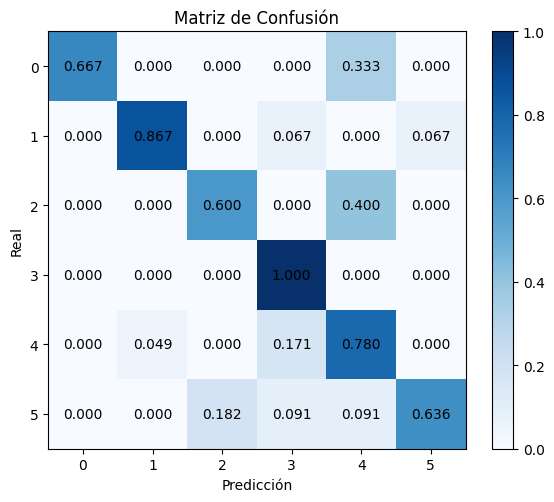

In [57]:
from utils.visual import print_cm

print_cm(y_test_area, y_pred_area)

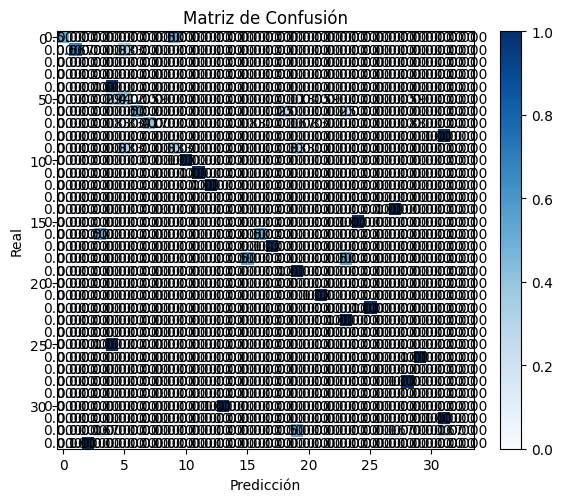

In [58]:
print_cm(y_test_sub, y_pred_sub)

### Clasificación subareas proba

In [170]:
from scipy.special import softmax
from sklearn.metrics.pairwise import cosine_similarity

ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

def sim_vectors(pub_vec, ocde_vecs):
    sims = ocde_vecs @ pub_vec
    return sims

class subarea_hierarchical_classifier: 
    def __init__(self, models_dict):
        self.models_dict = models_dict
    
    def predict_area(self, embedding):
        preds = []
        for key, model in self.models_dict.items():
            preds.append(model.predict(embedding))
        preds = np.array(preds)
        preds = np.transpose(preds)
        return preds
    
    def predict_proba_area0(self, embedding):
        prob = []
        for key, model in self.models_dict.items():
            p = model.predict_proba(embedding)
            prob.append(p)
        prob = np.array(prob)
        prob = np.transpose(prob)
        return prob[1]

    def predict_proba_area1(self, embedding):
        all_prob = []
        for key, model in loaded_models.items():
            prob = model.predict_proba(embedding)
            len_prob = len(prob)
            model_prob = []
            for idx in range(len_prob):
                if prob[idx, 0]>prob[idx, 1]:
                    model_prob.append(0)
                else: 
                    model_prob.append(prob[idx, 1])
                    
            all_prob.append(model_prob)
                
        all_prob = np.transpose(all_prob)
        
        return all_prob
    
    def predict_proba_area(self, embedding):
        all_prob = []
        for key, model in loaded_models.items():
            prob = model.predict_proba(embedding)  # shape (n_samples, 2)
            model_prob = np.where(prob[:, 0] > prob[:, 1], 0, prob[:, 1])
            all_prob.append(model_prob)

        return np.column_stack(all_prob)  # transponer en el mismo paso

    def compute_similarity0(self, embedding, emb_ocde):
        similarity_matrix = []
        for embed in embedding:
            sim = sim_vectors(embed, emb_ocde)
            similarity_matrix.append(sim)
        
        return np.array(similarity_matrix)
    
    def compute_similarity(self, embedding, emb_ocde, use_cosine=True):
        if use_cosine is not None:
            return cosine_similarity(embedding, emb_ocde)  # (n_samples, n_ocde)
        else:
            return np.array([sim_vectors(embed, emb_ocde) for embed in embedding])
    
    def compute_num_subkeys(self, ocde_hierarchy, ocde_area):
        num_subkeys = []
        for area in ocde_area:
            n = len(ocde_hierarchy[area])
            #print(area, n)
            num_subkeys.append(n)
        return np.array(num_subkeys)
    
    def predict_subarea(self, embedding, emb_ocde, ocde_area, ocde_keys):
        #Predexir area OCDE con modelo de ML 
        pred = self.predict_area(embedding)
        #Cálculo de similaridad entre textos y subcategorías OCDE
        similarity_matrix = self.compute_similarity(embedding, emb_ocde)
        #Número de subclaves por area OCDE
        num_subkeys = self.compute_num_subkeys(ocde_hierarchy, ocde_area)
        #Se expande la matriz de predicciones de modelos de ML utilizando cantidad de claves por modelo
        pred_expanded = np.repeat(pred, num_subkeys, axis=1)
        
        #Se utiliza matriz expandida para eliminar de selección subareas OCDE que no hayan 
        #Sido seleccionadas por modelos de ML
        new_similarity = similarity_matrix*pred_expanded
        #Se obtienen posiciones de subareas OCDE seleccionadas
        best_idx = np.argmax(new_similarity, axis=1)
        rea, sub = [], []
      
        for idx in best_idx:
            rea1, sub1 = ocde_keys[idx]
            rea.append(rea1)
            sub.append(sub1)

        return np.array(rea), np.array(sub)

    def predict_subarea_proba(self, embedding, emb_ocde, ocde_area, ocde_keys, use_softmax = None):
        #Predexir area OCDE con modelo de ML 
        prob = self.predict_proba_area(embedding)
        #Cálculo de similaridad entre textos y subcategorías OCDE
        similarity_matrix = self.compute_similarity(embedding, emb_ocde)
        #Número de subclaves por area OCDE
        num_subkeys = self.compute_num_subkeys(ocde_hierarchy, ocde_area)
        #Se expande la matriz de predicciones de modelos de ML utilizando cantidad de claves por modelo
        prob_expanded = np.repeat(prob, num_subkeys, axis=1)
    
        #Se utiliza matriz expandida para eliminar de selección subareas OCDE que no hayan 
        #Sido seleccionadas por modelos de ML
        if use_softmax is not None:
            similarity_matrix = softmax(similarity_matrix)
            
        new_similarity = similarity_matrix*prob_expanded
        #Se obtienen posiciones de subareas OCDE seleccionadas
        best_idx = np.argmax(new_similarity, axis=1)
        rea, sub = [], []
      
        for idx in best_idx:
            rea1, sub1 = ocde_keys[idx]
            rea.append(rea1)
            sub.append(sub1)

        return np.array(rea), np.array(sub)  
        

In [171]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated_subocde.csv")
df = pd.read_csv(filepath)

In [172]:
import os
import joblib

# Áreas OCDE
ocde_area = [
    "Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
    "Agricultural Sciences", "Social Sciences", "Humanities"
]

save_model_path = "/tmp/ocde/models_1"

# Diccionario donde quedarán los modelos cargados
loaded_models = {}

for area in ocde_area:
    model_filename = os.path.join(save_model_path, f"{area}_model.pkl")
    if os.path.exists(model_filename):
        loaded_models[area] = joblib.load(model_filename)
        print(f"✅ Modelo {area} cargado desde {model_filename}")
    else:
        print(f"⚠️ No se encontró el archivo para {area}: {model_filename}")

✅ Modelo Natural Sciences cargado desde /tmp/ocde/models_1/Natural Sciences_model.pkl
✅ Modelo Engineering and Technology cargado desde /tmp/ocde/models_1/Engineering and Technology_model.pkl
✅ Modelo Medical and Health Sciences cargado desde /tmp/ocde/models_1/Medical and Health Sciences_model.pkl
✅ Modelo Agricultural Sciences cargado desde /tmp/ocde/models_1/Agricultural Sciences_model.pkl
✅ Modelo Social Sciences cargado desde /tmp/ocde/models_1/Social Sciences_model.pkl
✅ Modelo Humanities cargado desde /tmp/ocde/models_1/Humanities_model.pkl


In [173]:
area_ocde_transform = {
    'CIENCIAS NATURALES': 'Natural Sciences',
    'CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD': 'Medical and Health Sciences',
    'HUMANIDADES': 'Humanities',
    'CIENCIAS AGRÍCOLAS': 'Agricultural Sciences', 
    ' INGENIERÍA, TECNOLOGÍA': 'Engineering and Technology',
    'CIENCIAS SOCIALES': 'Social Sciences',
}

df["area_ocde_trad"] = df["Categoria Disciplina"].replace(area_ocde_transform)

In [174]:
from models.specter import embed_texts
from sklearn.preprocessing import LabelEncoder
from models.specter import embed_texts
from utils.dataset import gen_dataset_select_cols

#Lectura de codigos 
codes_test = dataset_index["Test"]
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
col_test = "Sub_Area_Disciplina_trad"
X_test, y_test_sub, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)
col_test = "area_ocde_trad"
_, y_test_area, _= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)
    
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
   
X_test =  embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)
print(X_test.shape)
#"Natural Sciences", "Engineering and Technology", "Medical and Health Sciences",
#"Agricultural Sciences", "Social Sciences", "Humanities"

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(82, 768)


In [175]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from models.similarity import build_ocde_texts

#Build ocde texts
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

#Predecir area y subarea OCDE
shc = subarea_hierarchical_classifier(loaded_models) 
area, subarea = shc.predict_subarea_proba(X_test, emb_ocde, ocde_area, ocde_keys)

#Evaluar resultados
le_area = LabelEncoder()
#Area
y_test_area = le_area.fit_transform(y_test_area)
y_pred_area = le_area.transform(area)
#Subarea
subareas_list = []
for sub in ocde_keys:
    subareas_list.append(sub[1])
le_sub  = LabelEncoder()
le_sub.fit(subareas_list)
y_test_sub = le_sub.transform(y_test_sub)
y_pred_sub = le_sub.transform(subarea)
#Compute f1-score
f1_area = f1_score(y_test_area, y_pred_area, average ="macro")
f1_sub = f1_score(y_test_sub, y_pred_sub, average ="macro")
print("f1:", f1_area, f1_sub)
#Compute acc
acc_area = accuracy_score(y_test_area, y_pred_area)
acc_sub = accuracy_score(y_test_sub, y_pred_sub)
print("acc:", acc_area, acc_sub)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
f1: 0.7360071301247771 0.34660494734024144
acc: 0.8170731707317073 0.5487804878048781


['Agricultural Sciences' 'Engineering and Technology' 'Humanities'
 'Medical and Health Sciences' 'Natural Sciences' 'Social Sciences']


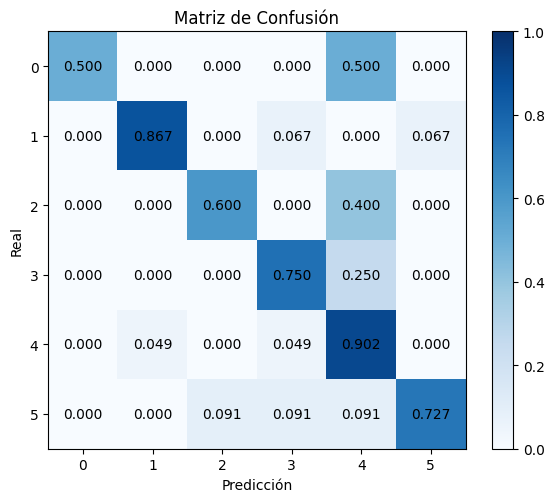

In [143]:
from utils.visual import print_cm

print(le_area.classes_)
print_cm(y_test_area, y_pred_area)

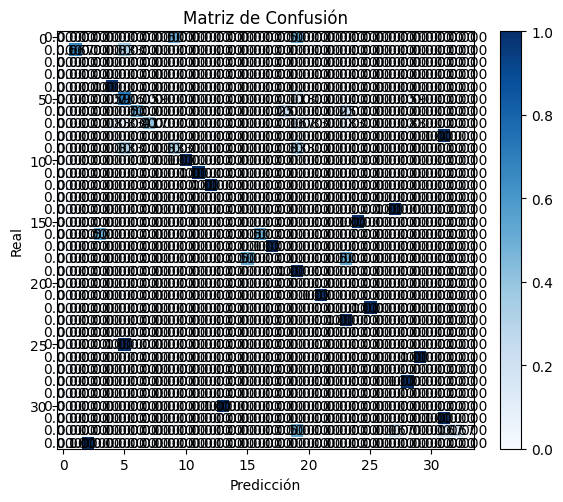

In [144]:
print_cm(y_test_sub, y_pred_sub)

# 4) Similarity on test dataset

### Dictionary

In [59]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}


### Eval similarity

In [60]:
from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
from models.similarity import build_ocde_texts

path = "/tmp/ocde/new_data"
filepath=os.path.join(path, "new_data_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_translated_subocde.csv")
df = pd.read_csv(filepath)

area_ocde_transform = {
    'CIENCIAS NATURALES': 'Natural Sciences',
    'CIENCIAS MÉDICAS, CIENCIAS DE LA SALUD': 'Medical and Health Sciences',
    'HUMANIDADES': 'Humanities',
    'CIENCIAS AGRÍCOLAS': 'Agricultural Sciences', 
    ' INGENIERÍA, TECNOLOGÍA': 'Engineering and Technology',
    'CIENCIAS SOCIALES': 'Social Sciences',
}

df["area_ocde_trad"] = df["Categoria Disciplina"].replace(area_ocde_transform)

#Drop nan de ["AreaOCDE"]
df = df.dropna(subset=["area_ocde_trad"]).reset_index(drop=True)
df["area_ocde_trad"] = df["area_ocde_trad"].str.lower()

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X, _, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names,
                                       test_col = "area_ocde_trad")


#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [61]:
from models.similarity import classify_two_stage

# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————



# 5) Clasificar cada publicación
df_test["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df_test["clasificaciones"] = df_test["clasificaciones"].astype(str).str.lower()

Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']


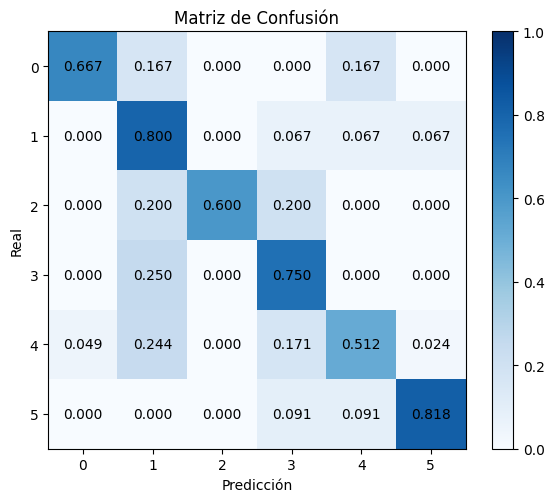

f1-score 0.6389905845788199


In [62]:
from sklearn.preprocessing import LabelEncoder
from utils.visual import print_cm

le = LabelEncoder()
y = le.fit_transform(df_test["area_ocde_trad"])
preds = le.transform(df_test["clasificaciones"])

print("Classes name:", le.classes_)
print_cm(y, preds)
print("f1-score", f1_score(y, preds, average="macro"))

In [64]:
print("acc", accuracy_score(y, preds))

acc 0.6341463414634146


In [150]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity(embedding, emb_ocde, use_cosine=None):
    if use_cosine is not None:
        return cosine_similarity(embedding, emb_ocde)  # (n_samples, n_ocde)
    else:
        return np.array([sim_vectors(embed, emb_ocde) for embed in embedding])

def compute_similarity0(embedding, emb_ocde):
    similarity_matrix = []
    for embed in embedding:
        sim = sim_vectors(embed, emb_ocde)
        similarity_matrix.append(sim)
    
    return np.array(similarity_matrix)

def get_subarea(similarity_matrix):

    best_idx = np.argmax(similarity_matrix, axis=1)
    rea, sub = [], []
    
    for idx in best_idx:
        rea1, sub1 = ocde_keys[idx]
        rea.append(rea1)
        sub.append(sub1)

    return np.array(rea), np.array(sub)  


#Subarea
col_test = "Sub_Area_Disciplina_trad"
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                test_col=col_test)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

similarity_matrix = compute_similarity(X_test, emb_ocde, use_cosine = True)
area, subarea = get_subarea(similarity_matrix)
#Subarea
le_area.fit(subareas_list)
y_test_sub = le_area.transform(y_test)
y_pred_sub = le_area.transform(subarea)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [152]:
#Compute f1-score
f1_sub = f1_score(y_test_sub, y_pred_sub, average ="macro")
print("f1 sub:", f1_sub)
#Compute acc
acc_sub = accuracy_score(y_test_sub, y_pred_sub)
print("acc sub:", acc_sub)

f1 sub: 0.28077509791795513
acc sub: 0.43902439024390244


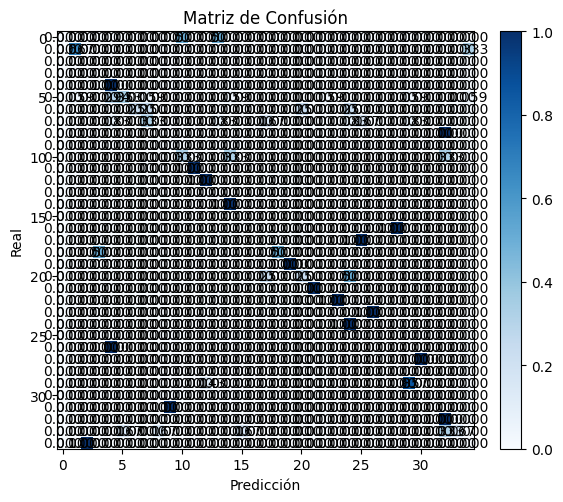

In [153]:
print_cm(y_test_sub, y_pred_sub)

### Save

In [ ]:
from utils.mlflow import mlflow_ckeckpoint_generic

exp_info = {
    'exp_name': "test_MLflow_local",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "Experiment_type": "similarity, without training",
    "cols": cols,
    "vectorization_model": BASE_MODEL,
}

extra_artifacts = {
    "dataset_data_splits": dataset_index,
}

mlflow_ckeckpoint_generic(exp_info, preds, y, df_test, save_preds=True, lang_es=df_test["Español"], 
                          extra_parms=extra_parms, extra_artifacts=extra_artifacts, mode="server", 
                          mode_classification="multiclass")


Current tracking uri: http://mlflow-server:5000
🏃 View run similarity, without training at: http://mlflow-server:5000/#/experiments/17/runs/eccfffe5b3e64326ac7a60fc6602d85e
🧪 View experiment at: http://mlflow-server:5000/#/experiments/17
